--- Starting Simple Batch Visualization ---

--- Running Energy Plots for Simple Batch ---
C:\Users\sabil\AppData\Local\Temp\ipykernel_23072\3868728078.py:233: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


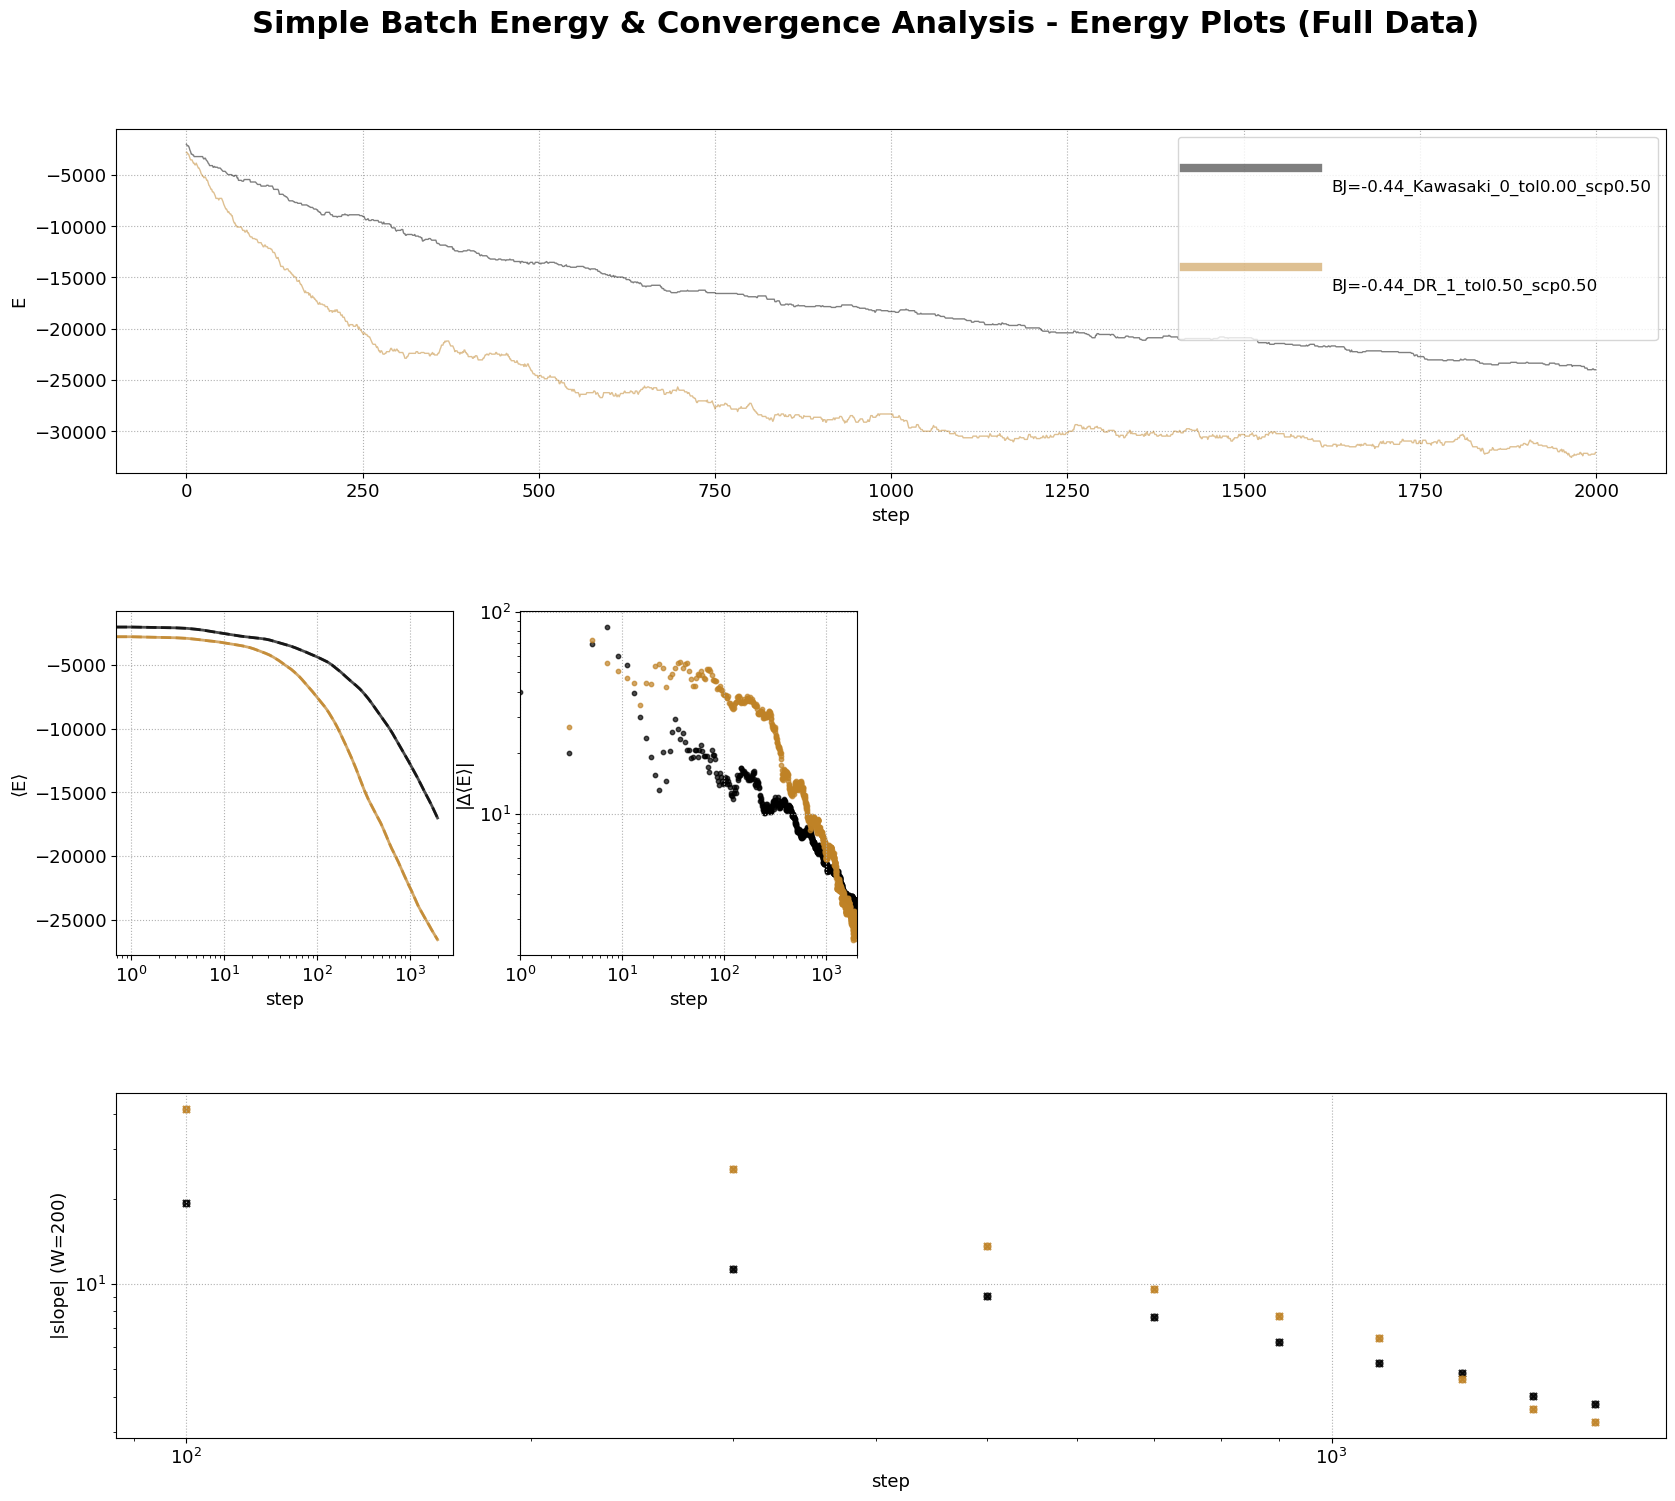

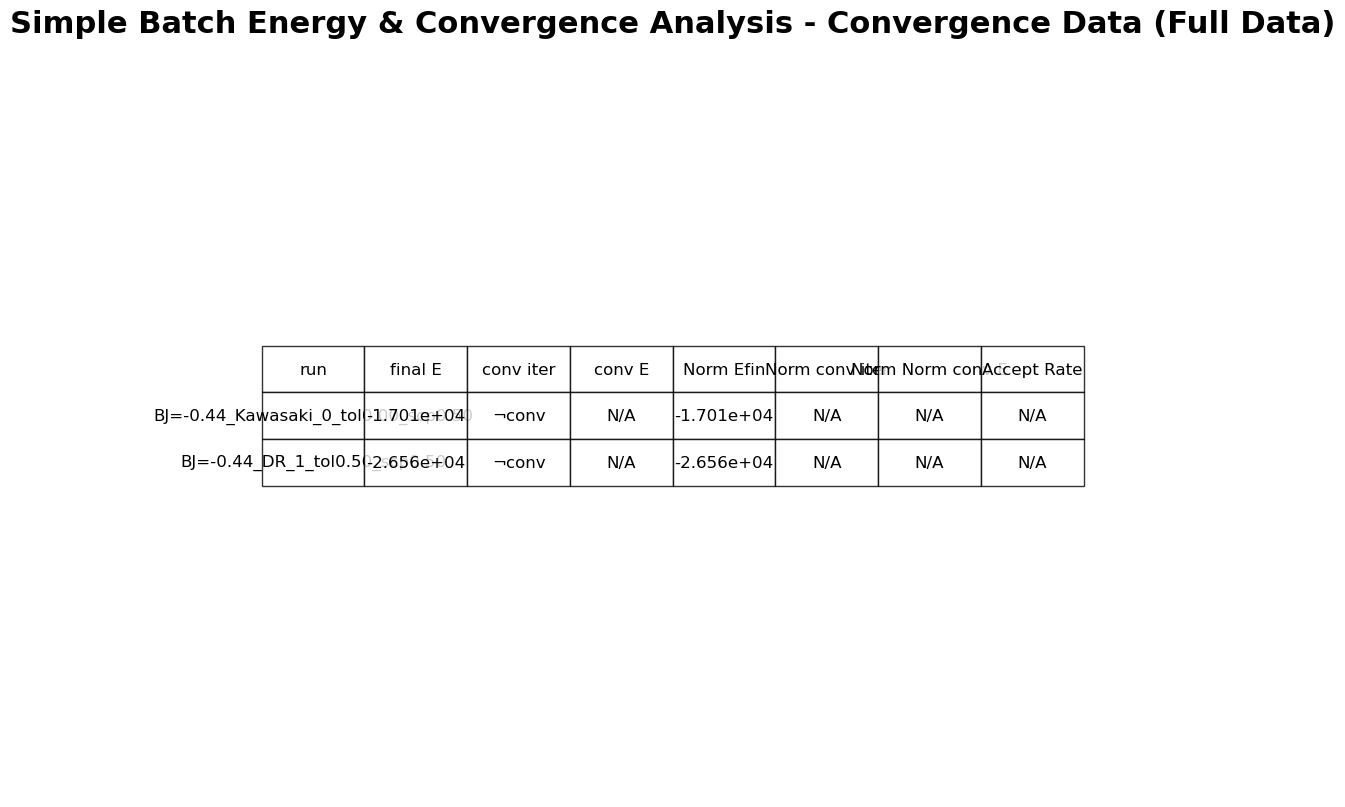

C:\Users\sabil\AppData\Local\Temp\ipykernel_23072\3868728078.py:361: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


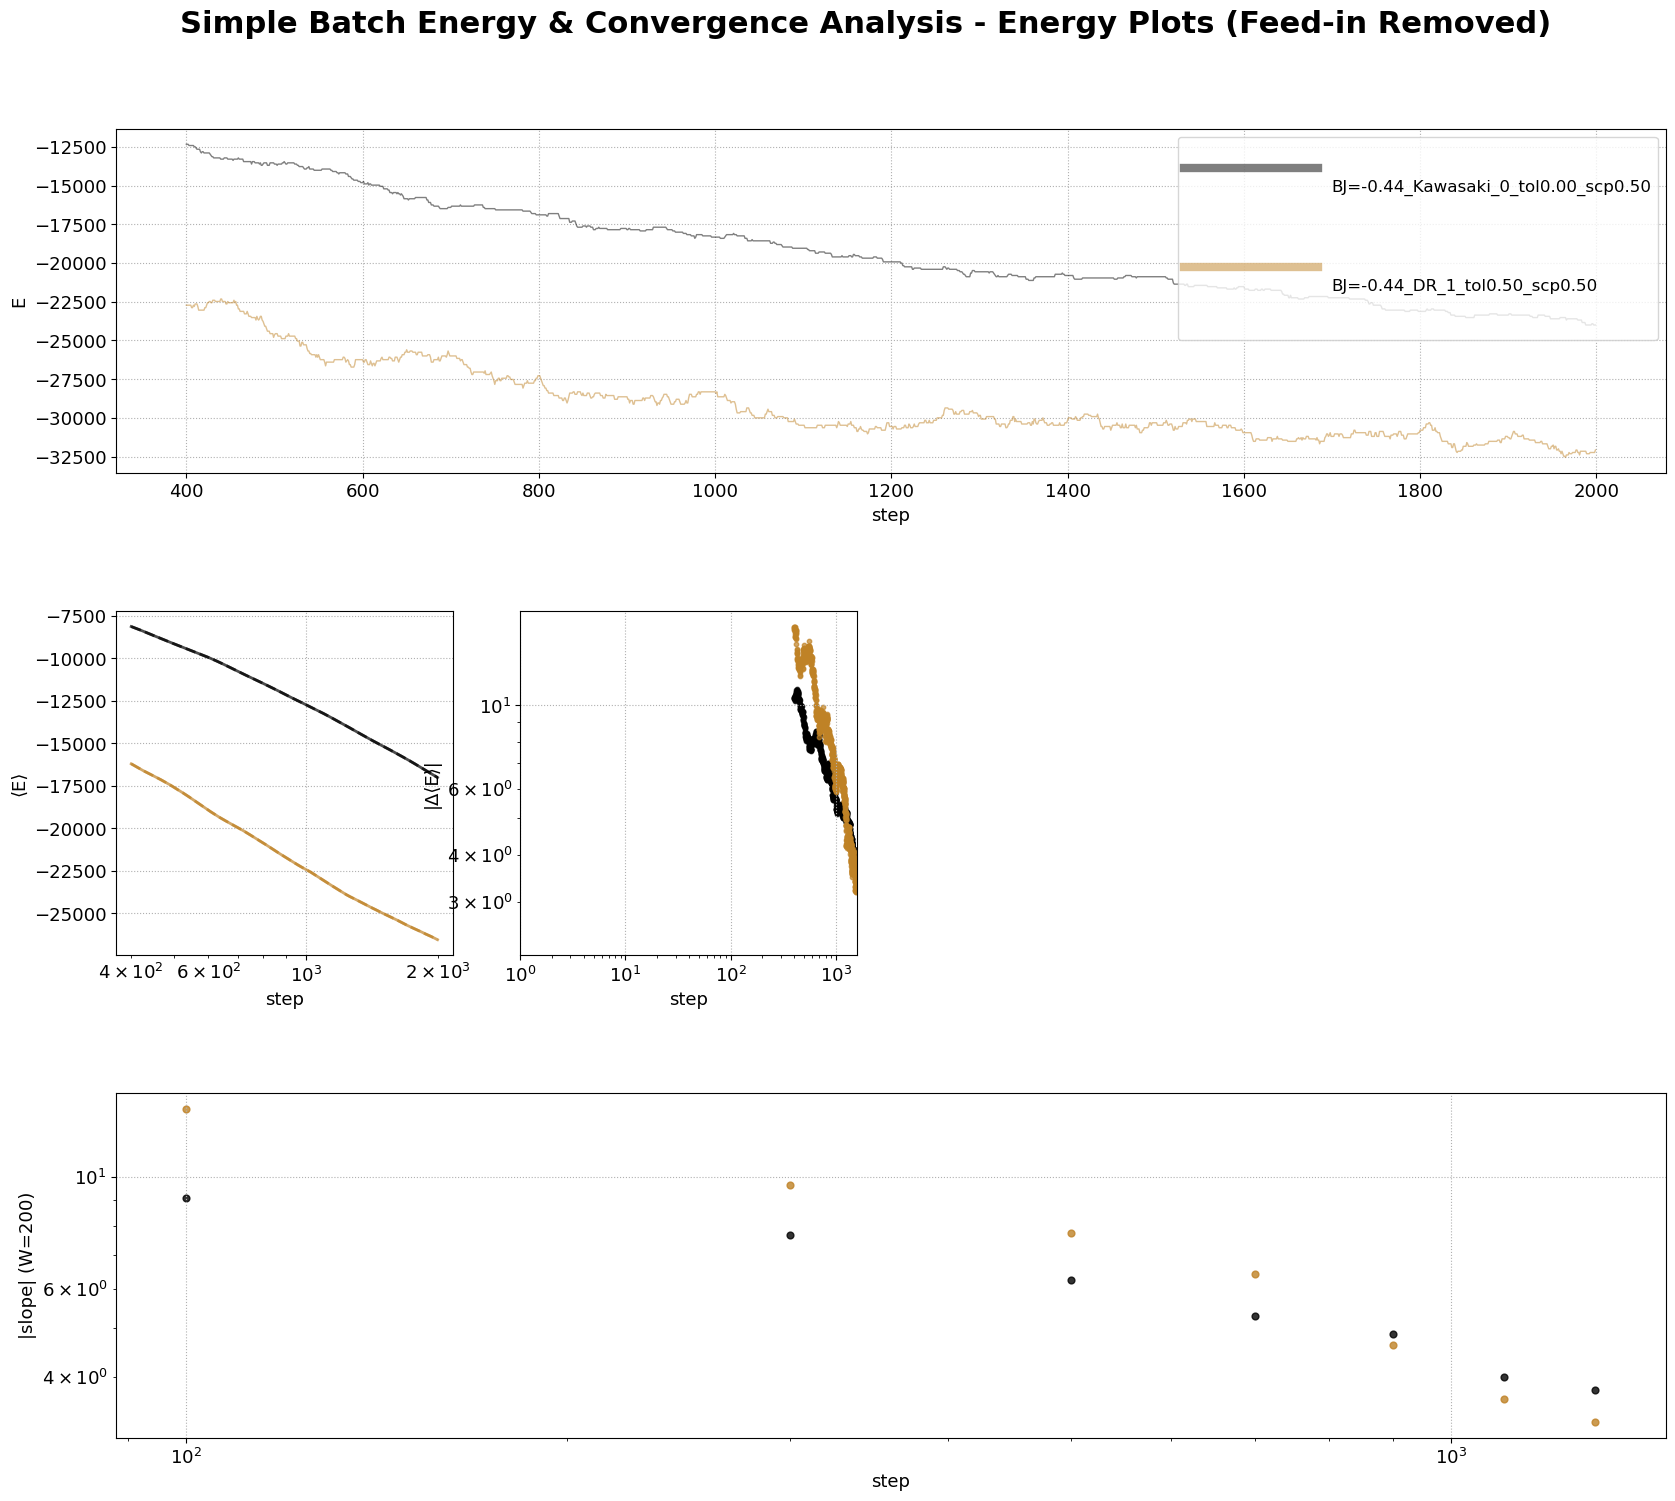

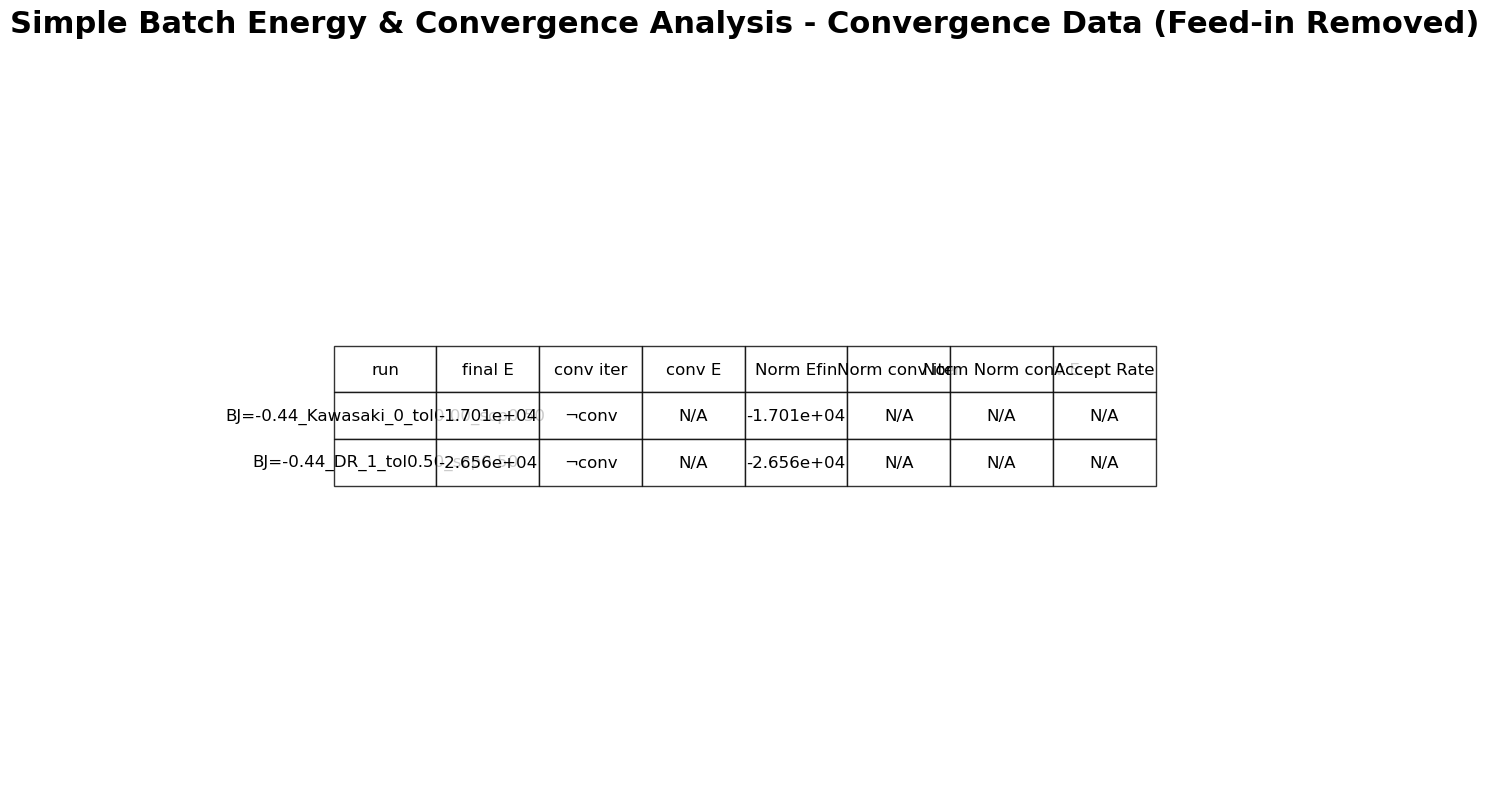

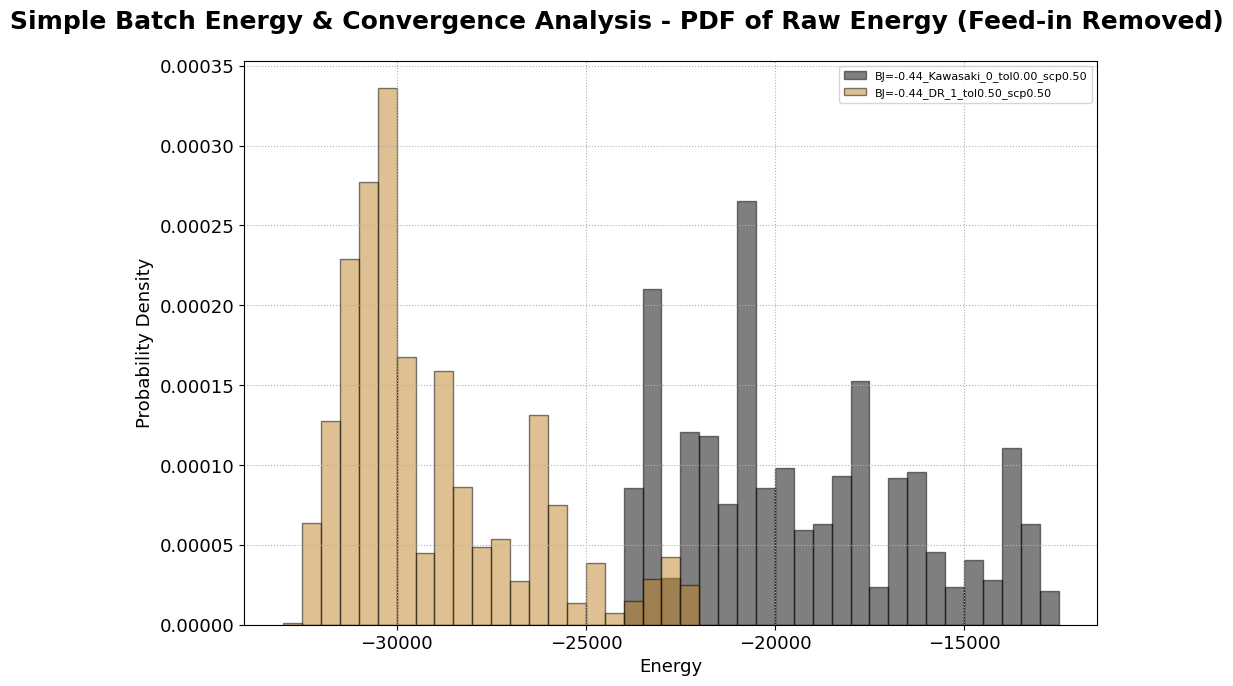


--- Running Static Grid Plots for Simple Batch ---
Debug: Plotting static grid from BJ=-0.44_Kawasaki_0_tol0.00_scp0.50_GridConfig.csv
Debug: Plotting static grid from BJ=-0.44_DR_1_tol0.50_scp0.50_GridConfig.csv

--- Creating Animations for Simple Batch ---
--- Simple Batch Visualization Complete ---


In [5]:
from __future__ import annotations
from pathlib import Path
from typing import List, Tuple, Dict, Any
import colorsys, itertools, math, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.animation as animation
import re # For parsing the list of tuples from CSV
import sys # For debug printing to stderr

# ---------------------------------------------------------------------
# 0. palette helpers
# ---------------------------------------------------------------------
BASE_COLOURS = {
    "NewMC":              "#ffcc99",  # Light orange
    "DR":                 "#ffcccc",  # Light red
    "NewMC_Expand":       "#ccffcc",  # Light green
    "NewMC_Restricted":   "#ccccff",  # Light blue
    "NewMC_Biased":       "#ffffcc",  # Light yellow
    "NewMC_Restricted_Expand": "#ffccff", # Light magenta
    "NewMC_Biased_Expand":     "#ccffff", # Light cyan
    "Kawasaki":           "#ffcccc",  # Light red
    "Kawasaki_Black":     "#000000",  # Dark black
}

def _anchor_colour(stem:str)->str:
    for k in sorted(BASE_COLOURS,key=len,reverse=True):
        if stem.startswith(k): return BASE_COLOURS[k]
    return "#808080"

def _tint_red(hex_colour:str,factor:float)->str:
    r,g,b=to_rgb(hex_colour)
    r=min(1.0, r*factor)
    return to_hex((r,g,b))

def _tint_green(hex_colour:str,factor:float)->str:
    r,g,b=to_rgb(hex_colour)
    g=min(1.0, g*factor)
    return to_hex((r,g,b))

def _tint_blue(hex_colour:str,factor:float)->str:
    r,g,b=to_rgb(hex_colour)
    b=min(1.0, b*factor)
    return to_hex((r,g,b))

def get_distinct_colors(n):
    """
    Generates n distinct colors. First color is black.
    """
    colors = ["#000000"]  # Black for the first color
    if n > 1:
        # Use HSV to get perceptually distinct colors
        # Start hue from a non-zero value to avoid very dark colors close to black
        for i in range(n - 1):
            hue = (i / (n - 1)) * 0.8 + 0.1 # Spread hues between 0.1 and 0.9
            # Ensure good saturation and value for visibility
            saturation = 0.8 # Fixed saturation
            value = 0.75 # Fixed value
            rgb = colorsys.hsv_to_rgb(hue, saturation, value)
            colors.append(to_hex(rgb))
    return colors

# ---------------------------------------------------------------------
# 1. filename / colour / label factory
# ---------------------------------------------------------------------
def build_filenames(*, BJ:str, include_kawasaki:bool,
                      base_variants:List[str], signifiers:List[List[str]], cluster_types:List[str]
                    )->Tuple[List[str],List[str],List[str],List[str],List[str],List[str]]:
    csv,tbl,col,leg,leg_col,expand=[],[],[],[],[],[]

    if include_kawasaki:
        # Kawasaki specific filename format
        fn=f"BJ={BJ}_Kawasaki_0_tol0.00_scp0.00.csv"
        print(f"Trying file: {fn}", file=sys.stderr)
        csv.append(fn)
        tbl.append("Kawasaki")
        col.append(BASE_COLOURS["Kawasaki_Black"])
        leg.append("Kawasaki")
        leg_col.append(BASE_COLOURS["Kawasaki_Black"])

    # Iterate through base variants, cluster types, and signifier combinations
    for stem in base_variants:
        for ct in cluster_types:
            anchor = _anchor_colour(stem)
            name = f"{stem}_{ct}"
            # Assuming signifiers[0] is for 'tol' and signifiers[1] is for 'scp'
            for j, signifier_1 in enumerate(signifiers[0]): # e.g., tol values
                for k, signifier_2 in enumerate(signifiers[1]): # e.g., scp values
                    fn_signifier = f"BJ={BJ}_{name}_{signifier_1}_{signifier_2}.csv"
                    csv.append(fn_signifier)
                    tbl.append(f"{name}_{signifier_1}_{signifier_2}")

                    # Calculate tint factors based on position in both loops
                    # Using much smaller tint ranges for subtler variation
                    tint1 = 0.8 + (0.4 * j/len(signifiers[0])) # First tint varies from 0.8 to 1.2
                    tint2 = 0.8 + (0.4 * k/len(signifiers[1])) # Second tint varies from 0.8 to 1.2
                    # Apply both tints sequentially
                    tinted_color = _tint_red(_tint_green(anchor, tint1), tint2)
                    col.append(tinted_color)

                    # Only add to legend for specific iterations (e.g., first and last of the inner loop)
                    # This helps prevent an overly cluttered legend
                    if k == 0 or k == len(signifiers[1])-1:
                        leg.append(f"{name}_{signifier_1}_{signifier_2}")
                        leg_col.append(tinted_color)
                    expand.append(fn_signifier)
    return csv,tbl,col,leg,leg_col,expand

# ---------------------------------------------------------------------
# 2. compare_runs – energy plots, slopes, convergence table
# ---------------------------------------------------------------------
def compare_runs(csv_files,*,table_labels,curve_colours,
                 legend_labels,legend_colours,
                 title="Energy & Convergence Analysis"):

    plt.rcParams.update({'font.size':13})

    # --- Figure 1: Original Energy Plots ---
    fig1 = plt.figure(figsize=(20, 17))
    gs1 = fig1.add_gridspec(3, 4, height_ratios=[1, 1, 1], hspace=0.4)

    ax_raw = fig1.add_subplot(gs1[0,:])
    ax_E,ax_dE = fig1.add_subplot(gs1[1,0]), fig1.add_subplot(gs1[1,1])
    ax_slope = fig1.add_subplot(gs1[2,:])

    fig1.suptitle(title + " - Energy Plots (Full Data)", fontsize=22, fontweight="bold", y=0.95)

    lengths = [len(pd.read_csv(f)) for f in csv_files if Path(f).is_file()]
    if not lengths: return
    W = max(50,min(1000,min(lengths)//10))
    thr = 1e-4
    streak = max(3,min(10,W//100))
    max_steps_full = 0 # Max steps for full data plots

    T_full_data = {k:[] for k in("run","Efin","conv_iter","conv_E",
                                  "norm_Efin","norm_conv_iter","norm_conv_E", "acceptance_rate")}
    all_filtered_energies = {} # Dictionary to store energies and weights for each run

    # Loop for plotting full data
    for fp, lbl_tbl, col, lbl_leg in zip(csv_files, table_labels, curve_colours,
                                         itertools.cycle(legend_labels or [None])):
        p = Path(fp)
        if not p.is_file(): continue
        try:
            df = pd.read_csv(p)
            if "Energy" not in df.columns: continue

            steps = np.arange(len(df))
            max_steps_full = max(max_steps_full,len(df))
            E = df["Energy"].ffill().bfill()
            ax_raw.plot(steps,E,lw=1,color=col,alpha=0.5,label=lbl_leg)

            cum = E.expanding().mean()
            ax_E.plot(steps,cum,lw=2,color=col,alpha=0.7)

            if "Total_Acceptances" in df.columns and "Move_Attempts" in df.columns:
                acceptance_rate = (df["Total_Acceptances"].iloc[-1] * 100.0 / df["Move_Attempts"].iloc[-1]) if df["Move_Attempts"].iloc[-1] > 0 else 0.0
            else:
                acceptance_rate = float('nan')

            wn = None
            weights = None
            if "Norm" in df.columns:
                N_norm = df["Norm"].replace([np.inf,-np.inf,0],np.nan).ffill().bfill()
                #eff = (1-N_norm)/N_norm + 1
                eff = (1-N_norm)*0/N_norm + 1 # This line seems to set eff to 1 always if N_norm is a number. Is this intended?
                wn = (E*eff).cumsum()/eff.cumsum()
                weights = eff  # Store weights for histogram
                ax_E.plot(steps,wn,lw=2,ls="--",color=col,alpha=0.7)

            stride = max(1,len(steps)//1000)
            ax_dE.scatter(steps[1::stride],np.abs(np.diff(cum))[::stride],
                          s=10,alpha=.7,color=col)
            conv = nconv = None
            if len(cum)>=2*W:
                idx = np.arange(0,len(cum)-W,W)
                sl = np.array([(cum[i+W]-cum[i])/W for i in idx])
                ax_slope.scatter(idx+W/2,np.abs(sl),s=24,alpha=.8,color=col)
                conv = next((int(idx[i]) for i in range(len(sl)-streak+1)
                             if np.all(np.abs(sl[i:i+streak])<thr)),None)
            if wn is not None and len(wn)>=2*W:
                idxN = np.arange(0,len(wn)-W,W)
                slN = np.array([(wn[i+W]-wn[i])/W for i in idxN])
                ax_slope.scatter(idxN+W/2,np.abs(slN),
                                  marker="x",s=26,alpha=.8,color=col)
                nconv = next((int(idxN[i]) for i in range(len(slN)-streak+1)
                              if np.all(np.abs(slN[i:i+streak])<thr)),None)

            # Store filtered energies with their color and weights
            start_index_for_80_percent = int(0.2 * len(df))
            all_filtered_energies[lbl_tbl] = {
                'energies': df["Energy"].iloc[start_index_for_80_percent:].tolist(),
                'color': col,
                'weights': weights.iloc[start_index_for_80_percent:].tolist() if weights is not None else None,
                'steps': steps[start_index_for_80_percent:].tolist(),
                'cum': cum.iloc[start_index_for_80_percent:].tolist(),
                'wn': wn.iloc[start_index_for_80_percent:].tolist() if wn is not None else None
            }

            # Populate table data for full run
            T_full_data["run"].append(lbl_tbl)
            T_full_data["Efin"].append(f"{cum.iloc[-1]:.4g}")
            T_full_data["conv_iter"].append(conv if conv is not None else "¬conv")
            T_full_data["conv_E"].append(f"{cum[conv]:.4g}" if conv is not None else "N/A")
            T_full_data["acceptance_rate"].append(f"{acceptance_rate:.2f}%" if not np.isnan(acceptance_rate) else "N/A")
            if wn is not None:
                T_full_data["norm_Efin"].append(f"{wn.iloc[-1]:.4g}")
                T_full_data["norm_conv_iter"].append(nconv if nconv is not None else "N/A")
                T_full_data["norm_conv_E"].append(f"{wn[nconv]:.4g}" if nconv is not None else "N/A")
            else:
                T_full_data["norm_Efin"].append("N/A")
                T_full_data["norm_conv_iter"].append("N/A")
                T_full_data["norm_conv_E"].append("N/A")

        except Exception as e: print(f"[warn] {p.name}: {e}", file=sys.stderr)

    # Cosmetics for Figure 1 axes (Full Data)
    ax_raw.set(xlabel="step",ylabel="E"); ax_raw.grid(ls=":")
    if any(legend_labels):
        ax_raw.legend(fontsize=12, handleheight=8, handlelength=8)
        for legline in ax_raw.get_legend().get_lines():
            legline.set_linewidth(6.0)

    ax_E.set(xscale="log",xlabel="step",ylabel="⟨E⟩"); ax_E.grid(ls=":")

    ax_dE.set(xscale="log",yscale="log",xlim=(1,max_steps_full),
              xlabel="step",ylabel="|Δ⟨E⟩|"); ax_dE.grid(ls=":")

    ax_slope.set(xscale="log",yscale="log",
                  xlabel="step",ylabel=f"|slope| (W={W})"); ax_slope.grid(ls=":")

    plt.tight_layout()
    fig1.savefig("energy_plots_full_data.png", dpi=300, bbox_inches="tight",
                  pad_inches=0.5, transparent=False)
    plt.show()

    # --- Figure 2: Original Convergence Table ---
    num_rows_full = len(T_full_data["run"])
    row_height_full = 0.5
    fig_height_full = max(8.5, 2 + (num_rows_full * row_height_full))

    fig2 = plt.figure(figsize=(20, fig_height_full))
    ax_tbl = fig2.add_subplot(111)
    ax_tbl.axis("off")

    fig2.suptitle(title + " - Convergence Data (Full Data)", fontsize=22, fontweight="bold", y=0.95)

    cell_text_full = list(zip(T_full_data["run"],T_full_data["Efin"],T_full_data["conv_iter"],T_full_data["conv_E"],
                              T_full_data["norm_Efin"],T_full_data["norm_conv_iter"],T_full_data["norm_conv_E"],
                              T_full_data["acceptance_rate"]))

    col_labels_full = ["run","final E","conv iter","conv E",
                       "Norm Efin","Norm conv iter","Norm Norm conv E",
                       "Accept Rate"]

    cell_scale_full = min(2.0, 20/num_rows_full)

    tbl_full = ax_tbl.table(cellText=cell_text_full,
                            colLabels=col_labels_full,
                            loc="center",
                            cellLoc="center")

    font_size_full = min(12, 160/num_rows_full)
    tbl_full.auto_set_font_size(False)
    tbl_full.set_fontsize(font_size_full)
    tbl_full.scale(cell_scale_full, cell_scale_full * 1.2)

    for cell in tbl_full._cells.values():
        cell.set_edgecolor('black')
        cell.set_facecolor('white')
        cell.set_alpha(0.8)

    plt.tight_layout()
    fig2.savefig("convergence_table_full_data.png", dpi=300, bbox_inches="tight",
                  pad_inches=0.5, transparent=False)
    plt.show()

    # --- Figure 3: Filtered Data Plots ---
    if all_filtered_energies:
        fig3 = plt.figure(figsize=(20, 17))
        gs3 = fig3.add_gridspec(3, 4, height_ratios=[1, 1, 1], hspace=0.4)

        ax_raw_f = fig3.add_subplot(gs3[0,:])
        ax_E_f,ax_dE_f = fig3.add_subplot(gs3[1,0]), fig3.add_subplot(gs3[1,1])
        ax_slope_f = fig3.add_subplot(gs3[2,:])

        fig3.suptitle(title + " - Energy Plots (Feed-in Removed)", fontsize=22, fontweight="bold", y=0.95)

        max_steps_filtered = 0
        T_filtered_data = {k:[] for k in("run","Efin","conv_iter","conv_E",
                                         "norm_Efin","norm_conv_iter","norm_conv_E",
                                         "acceptance_rate")}

        for run_name, run_data in all_filtered_energies.items():
            steps = run_data['steps']
            max_steps_filtered = max(max_steps_filtered, len(steps))
            
            # Plot raw energies
            ax_raw_f.plot(steps, run_data['energies'], lw=1, color=run_data['color'], alpha=0.5, label=run_name)
            
            # Plot cumulative average
            ax_E_f.plot(steps, run_data['cum'], lw=2, color=run_data['color'], alpha=0.7)
            
            if run_data['wn'] is not None:
                ax_E_f.plot(steps, run_data['wn'], lw=2, ls="--", color=run_data['color'], alpha=0.7)

            # Plot energy differences
            stride = max(1, len(steps)//1000)
            cum_array = np.array(run_data['cum'])
            ax_dE_f.scatter(steps[1::stride], np.abs(np.diff(cum_array))[::stride],
                            s=10, alpha=.7, color=run_data['color'])

            # Plot slopes
            if len(cum_array) >= 2*W:
                idx = np.arange(0, len(cum_array)-W, W)
                sl = np.array([(cum_array[i+W]-cum_array[i])/W for i in idx])
                ax_slope_f.scatter(idx+W/2, np.abs(sl), s=24, alpha=.8, color=run_data['color'])
                conv = next((int(idx[i]) for i in range(len(sl)-streak+1)
                             if np.all(np.abs(sl[i:i+streak])<thr)), None)
            else:
                conv = None

            # Populate filtered data table
            T_filtered_data["run"].append(run_name)
            T_filtered_data["Efin"].append(f"{run_data['cum'][-1]:.4g}")
            T_filtered_data["conv_iter"].append(conv if conv is not None else "¬conv")
            T_filtered_data["conv_E"].append(f"{run_data['cum'][conv]:.4g}" if conv is not None else "N/A")
            
            if run_data['wn'] is not None:
                T_filtered_data["norm_Efin"].append(f"{run_data['wn'][-1]:.4g}")
                T_filtered_data["norm_conv_iter"].append("N/A")  # Simplified for filtered data
                T_filtered_data["norm_conv_E"].append("N/A")    # Simplified for filtered data
            else:
                T_filtered_data["norm_Efin"].append("N/A")
                T_filtered_data["norm_conv_iter"].append("N/A")
                T_filtered_data["norm_conv_E"].append("N/A")
            
            # Calculate acceptance rate for filtered data
            T_filtered_data["acceptance_rate"].append(T_full_data["acceptance_rate"][T_full_data["run"].index(run_name)])

        # Cosmetics for Figure 3 axes (Filtered Data)
        ax_raw_f.set(xlabel="step", ylabel="E")
        ax_raw_f.grid(ls=":")
        if any(legend_labels):
            ax_raw_f.legend(fontsize=12, handleheight=8, handlelength=8)
            for legline in ax_raw_f.get_legend().get_lines():
                legline.set_linewidth(6.0)

        ax_E_f.set(xscale="log", xlabel="step", ylabel="⟨E⟩")
        ax_E_f.grid(ls=":")

        ax_dE_f.set(xscale="log", yscale="log", xlim=(1,max_steps_filtered),
                    xlabel="step", ylabel="|Δ⟨E⟩|")
        ax_dE_f.grid(ls=":")

        ax_slope_f.set(xscale="log", yscale="log",
                        xlabel="step", ylabel=f"|slope| (W={W})")
        ax_slope_f.grid(ls=":")

        plt.tight_layout()
        fig3.savefig("energy_plots_filtered_data.png", dpi=300, bbox_inches="tight",
                      pad_inches=0.5, transparent=False)
        plt.show()

        # --- Figure 4: Filtered Data Convergence Table ---
        num_rows_filtered = len(T_filtered_data["run"])
        row_height_filtered = 0.5
        fig_height_filtered = max(8.5, 2 + (num_rows_filtered * row_height_filtered))

        fig4 = plt.figure(figsize=(20, fig_height_filtered))
        ax_tbl_f = fig4.add_subplot(111)
        ax_tbl_f.axis("off")

        fig4.suptitle(title + " - Convergence Data (Feed-in Removed)", fontsize=22, fontweight="bold", y=0.95)

        cell_text_filtered = list(zip(T_filtered_data["run"],T_filtered_data["Efin"],
                                      T_filtered_data["conv_iter"],T_filtered_data["conv_E"],
                                      T_filtered_data["norm_Efin"],T_filtered_data["norm_conv_iter"],
                                      T_filtered_data["norm_conv_E"],T_filtered_data["acceptance_rate"]))

        cell_scale_filtered = min(2.0, 20/num_rows_filtered)

        tbl_filtered = ax_tbl_f.table(cellText=cell_text_filtered,
                                      colLabels=col_labels_full,
                                      loc="center",
                                      cellLoc="center")

        font_size_filtered = min(12, 160/num_rows_filtered)
        tbl_filtered.auto_set_font_size(False)
        tbl_filtered.set_fontsize(font_size_filtered)
        tbl_filtered.scale(cell_scale_filtered, cell_scale_filtered * 1.2)

        for cell in tbl_filtered._cells.values():
            cell.set_edgecolor('black')
            cell.set_facecolor('white')
            cell.set_alpha(0.8)

        plt.tight_layout()
        fig4.savefig("convergence_table_filtered_data.png", dpi=300, bbox_inches="tight",
                      pad_inches=0.5, transparent=False)
        plt.show()

        # --- Figure 5: PDF Plot (Feed-in Removed) ---
        fig5 = plt.figure(figsize=(10, 7))
        ax_pdf = fig5.add_subplot(111)
        fig5.suptitle(title + " - PDF of Raw Energy (Feed-in Removed)", fontsize=18, fontweight="bold")

        # Create bins from min to max energy
        all_energies = [e for run in all_filtered_energies.values() for e in run['energies']]
        max_e = max(all_energies)
        min_e = min(all_energies)
        bin_start = math.floor(min_e/500) * 500 - 5
        bin_end = math.floor(max_e/500) * 500 - 5
        bins = np.arange(bin_start, bin_end + 500, 500)

        # Plot weighted histogram for each run
        for run_name, run_data in all_filtered_energies.items():
            weights = run_data['weights'] if run_data['weights'] is not None else None
            ax_pdf.hist(run_data['energies'], bins=bins, density=True, alpha=0.5,
                        weights=weights, color=run_data['color'], 
                        label=run_name, edgecolor='black')

        ax_pdf.set_xlabel("Energy")
        ax_pdf.set_ylabel("Probability Density")
        ax_pdf.grid(ls=":")
        ax_pdf.legend(fontsize=8)
        plt.tight_layout()
        fig5.savefig("energy_pdf_feed_in_removed.png", dpi=300, bbox_inches="tight",
                      pad_inches=0.5, transparent=False)
        plt.show()

# ---------------------------------------------------------------------
# 3. plot_grid (Modified for static plots; animation uses inline logic)
# ---------------------------------------------------------------------
def plot_grid(cfg_df:pd.DataFrame, *, title:str=None, figsize=(6,6),
              ax=None, save_path: Path = None, grid_size: int = None):
    """
    Plots the grid configuration.
    This function is primarily for STATIC plots now.
    Animation logic is handled directly in create_grid_animation for performance.
    """
    if grid_size is None:
        N = int(max(cfg_df["x"].max(), cfg_df["y"].max()) + 1) if not cfg_df.empty else 0
    else:
        N = grid_size
    
    if N == 0: # Handle case where N cannot be determined or df is empty
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "Empty Grid (No Config)", ha='center', va='center', transform=ax.transAxes, fontsize=16)
        ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[])
        if save_path:
            fig.savefig(save_path, dpi=250, bbox_inches="tight")
            plt.close(fig)
        else:
            plt.show()
        return

    fig, ax_local = plt.subplots(1, 1, figsize=figsize) # Always create new figure for static
    ax_local.set(xlim=(0, N), ylim=(0, N), aspect="equal", xticks=[], yticks=[])
    ax_local.set_title(title or "Grid Configuration", fontweight="bold")
        
    df_display = cfg_df.copy()
    df_display["y"] = N - 1 - df_display["y"] # Flip y for display

    # Draw grid cells and cluster IDs
    for _, r in df_display.iterrows():
        col = "#d62728" if r["species"] == 0 else "#1f77b4"
        alpha = 0.3 if r["cell_type"] == "INTERIOR" else 0.7
        rect = plt.Rectangle((r["x"], r["y"]), 1, 1,
                                 facecolor=col, alpha=alpha, ec='none')
        ax_local.add_patch(rect)

        txt = ax_local.text(r["x"]+.5, r["y"]+.5, str(r["cluster_id"]),
                        ha="center", va="center", fontsize=7, color='black')
        ax_local.add_artist(txt)
    
    if save_path:
        fig.savefig(save_path, dpi=250, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

# ---------------------------------------------------------------------
# Helper for parsing atom indices from string to (x,y) coordinates
# ---------------------------------------------------------------------
def parse_atom_indices_to_coords(indices_raw: any, grid_size: int) -> List[Tuple[int, int]]:
    """
    Parses a string of comma-separated integer indices into (x, y) coordinates.
    e.g., "1,5,8" -> [(1,0), (1,1), (0,2)] for a 3x3 grid.
    """
    if pd.isna(indices_raw) or indices_raw is None or str(indices_raw).strip() == "":
        return []
        
    s = str(indices_raw).strip('"').strip("'").strip() # Ensure stripping whitespace too
    
    if not s: # Check if string is empty after stripping quotes and whitespace
        return []
        
    try:
        indices = [int(x.strip()) for x in s.split(',') if x.strip()]
    except ValueError:
        print(f"Warning: Could not parse indices string: '{indices_raw}' (cleaned: '{s}'). Returning empty list.", file=sys.stderr)
        return []
    
    coords = []
    for idx in indices:
        if 0 <= idx < grid_size * grid_size:
            x = idx % grid_size
            y = idx // grid_size
            coords.append((x, y))
        else:
            print(f"Warning: Atom index {idx} out of bounds for grid size {grid_size}. Skipping.", file=sys.stderr)
    return coords

# ---------------------------------------------------------------------
# Helper for parsing GridConfig string to DataFrame
# ---------------------------------------------------------------------
def parse_grid_config_string(config_raw: any, N: int) -> pd.DataFrame:
    """
    Parses the GridConfig string into a DataFrame.
    The string format is "species|cluster_id|cell_type;species|cluster_id|cell_type;..."
    """
    if pd.isna(config_raw) or config_raw is None or str(config_raw).strip() == "":
        return pd.DataFrame(columns=['x', 'y', 'species', 'cluster_id', 'cell_type'])

    s = str(config_raw).strip('"').strip("'")
    if not s: # Check if string is empty after stripping quotes
        return pd.DataFrame(columns=['x', 'y', 'species', 'cluster_id', 'cell_type'])

    atoms_data = []
    cells_str = s.split(';')
    
    for i, cell_data_str in enumerate(cells_str):
        if not cell_data_str.strip(): # Skip empty strings from trailing semicolons or multiple
            continue
        try:
            parts = cell_data_str.split('|')
            if len(parts) != 3:
                # print(f"Warning: Malformed cell data '{cell_data_str}' at index {i}. Expected 3 parts, got {len(parts)}. Skipping.", file=sys.stderr)
                continue

            species_str, cluster_id_str, cell_type_str = parts
            x = i % N
            y = i // N
            species = int(species_str)
            cluster_id = int(cluster_id_str)
            cell_type = cell_type_str # Keep as string (B, I, A)
            atoms_data.append({'x': x, 'y': y, 'species': species, 'cluster_id': cluster_id, 'cell_type': cell_type})
        except ValueError as e:
            # print(f"Warning: Could not parse cell data '{cell_data_str}' at index {i}. Error: {e}. Skipping.", file=sys.stderr)
            pass
        except IndexError as e:
            # print(f"Warning: Malformed cell data string '{cell_data_str}' at index {i}. Error: {e}. Skipping.", file=sys.stderr)
            pass

    return pd.DataFrame(atoms_data)


# ---------------------------------------------------------------------
# 5. Animation Function
# ---------------------------------------------------------------------
def create_grid_animation(csv_file: Path, output_filename: str = "grid_animation.mp4", 
                            fps: int = 5, figsize=(6,6), max_frames: int = 1000, dpi: int = 100):
    """
    Creates an animation of the grid configuration, displaying two grids per frame:
    GridConfigStarting (left) and GridConfigPotential (right), with optimized updates.
    
    The animation iterates through original data rows, showing proposed changes and accepted changes.

    Args:
        csv_file (Path): Path to the main simulation CSV file.
        output_filename (str): Name of the output MP4 file.
        fps (int): Frames per second for the animation.
        figsize (tuple): Figure size for the entire animation frame.
        max_frames (int): Maximum number of iterations to animate from the CSV.
        dpi (int): Dots per inch for the output animation resolution. Lower for faster rendering.
    """
    print(f"Debug (create_grid_animation): Starting for {csv_file.name}", file=sys.stderr)

    if not csv_file.exists():
        print(f"Error: Simulation CSV file not found at {csv_file}", file=sys.stderr)
        return

    try:
        # Explicitly define data types for columns that should be strings
        dtype_mapping = {
            "GridConfigStarting": str,
            "GridConfigPotential": str,
            "PossiblyChanged": str,
            "AcceptedPossiblyChanged": str,
            "Accepted_Move": bool, # Ensure this is read as boolean
        }
        # Only load necessary columns
        df_sim = pd.read_csv(csv_file, dtype=dtype_mapping,
                             usecols=["GridConfigStarting", "GridConfigPotential", 
                                      "PossiblyChanged", "AcceptedPossiblyChanged", "Accepted_Move"])
        print(f"Debug (create_grid_animation): CSV loaded. Shape: {df_sim.shape}", file=sys.stderr)
    except Exception as e:
        print(f"Error reading simulation CSV {csv_file}: {e}", file=sys.stderr)
        return

    required_cols = ["GridConfigStarting", "GridConfigPotential", "PossiblyChanged", 
                     "AcceptedPossiblyChanged", "Accepted_Move"]
    if not all(col in df_sim.columns for col in required_cols):
        missing_cols = [col for col in required_cols if col not in df_sim.columns]
        print(f"Error: Required columns {missing_cols} not found in {csv_file.name}. Cannot create animation.", file=sys.stderr)
        return

    if df_sim.empty:
        print(f"Warning: CSV file {csv_file.name} is empty. No animation to create.", file=sys.stderr)
        return

    # Determine grid size N from the first valid GridConfigStarting entry
    N = 0
    for _, row in df_sim.iterrows():
        grid_config_str = str(row["GridConfigStarting"]) if pd.notna(row["GridConfigStarting"]) else ""
        cleaned_grid_config_str = grid_config_str.strip('"').strip("'")
        if cleaned_grid_config_str:
            num_cells = len(cleaned_grid_config_str.split(';'))
            N = int(math.sqrt(num_cells))
            if N * N != num_cells:
                print(f"Warning: GridConfigStarting string implies non-square grid or malformed data for '{csv_file.name}'. Num cells: {num_cells}. Trying to proceed with N={N}", file=sys.stderr)
            print(f"Debug (create_grid_animation): Determined grid size N={N} from first valid GridConfigStarting.", file=sys.stderr)
            break
    
    if N == 0:
        print(f"Error: Could not determine grid size N from GridConfigStarting column in {csv_file.name}. Cannot create animation.", file=sys.stderr)
        return

    # --- Pre-process all grid configurations and changed atoms ---
    # Store parsed DataFrames and coordinate lists for quick access
    preprocessed_data = []
    
    current_grid_config_df = None # To hold the "current" starting grid as it evolves

    for i in range(min(len(df_sim), max_frames)):
        row = df_sim.iloc[i]

        # Use the GridConfigStarting from the CSV row directly if it's the first frame
        if i == 0:
            starting_config_df = parse_grid_config_string(row["GridConfigStarting"], N)
        else:
            # The 'starting' config for the current iteration will be derived from the
            # 'current_displayed_grid_df' which is updated based on accepted moves.
            starting_config_df = None # Placeholder; actual logic is in `update`

        potential_config_df = parse_grid_config_string(row["GridConfigPotential"], N)
        
        possibly_changed_coords = parse_atom_indices_to_coords(row["PossiblyChanged"], N)
        accepted_possibly_changed_coords = parse_atom_indices_to_coords(row["AcceptedPossiblyChanged"], N)
        accepted_move = row["Accepted_Move"]

        preprocessed_data.append({
            "idx": i,
            "starting_config": starting_config_df, # Only truly used for the very first frame
            "potential_config": potential_config_df,
            "possibly_changed": possibly_changed_coords,
            "accepted_possibly_changed": accepted_possibly_changed_coords,
            "accepted_move": accepted_move
        })
    
    num_original_frames = len(preprocessed_data)
    total_animation_frames = num_original_frames * 3 # State, Proposed, Accepted (if any) or State, Proposed, Reset
    
    print(f"Creating animation for {csv_file.name} with {total_animation_frames} frames...", file=sys.stderr)
    if total_animation_frames == 0:
        print(f"Warning: No frames to animate. Skipping.", file=sys.stderr)
        return

    # Use a smaller figsize for rapid iteration
    fig, ax_grid = plt.subplots(1, 1, figsize=(4, 4)) # Reduced figsize
    ax_grid.set(xlim=(0, N), ylim=(0, N), aspect="equal", xticks=[], yticks=[])

    # Initialize all grid rectangles and text once
    grid_rects: Dict[Tuple[int, int], plt.Rectangle] = {}
    grid_texts: Dict[Tuple[int, int], plt.Text] = {}
    
    # Initialize the grid based on the very first starting configuration
    initial_config = preprocessed_data[0]["starting_config"]
    if initial_config.empty:
        print(f"Warning: Initial grid config is empty. Animation might be blank.", file=sys.stderr)
        ax_grid.text(N/2, N/2, "Empty Grid", ha='center', va='center', fontsize=8, color='gray') # Reduced font size

    # Draw the initial grid (all artists)
    for _, r in initial_config.iterrows():
        x_coord, y_coord = int(r["x"]), int(N - 1 - r["y"]) # Flip y for display
        
        rect_color = "#d62728" if r["species"] == 0 else "#1f77b4"
        rect_alpha = 0.3 if r["cell_type"] == "INTERIOR" else 0.7
        rect = plt.Rectangle((x_coord, y_coord), 1, 1, facecolor=rect_color, alpha=rect_alpha, ec='none')
        ax_grid.add_patch(rect)
        grid_rects[(x_coord, y_coord)] = rect

        txt = ax_grid.text(x_coord+.5, y_coord+.5, str(r["cluster_id"]),
                           ha="center", va="center", fontsize=5, color='black') # Reduced font size
        ax_grid.add_artist(txt)
        grid_texts[(x_coord, y_coord)] = txt

    # Initialize title artist
    title_artist = ax_grid.set_title("Iteration 0", fontweight="bold", fontsize=10) # Reduced font size
    
    # This will hold the current grid state that evolves.
    # It starts as a copy of the very first starting configuration.
    # We update it in place as moves are accepted.
    current_displayed_grid_df = initial_config.copy()
    
    # Map (x,y) to current species, cluster_id, cell_type for quick lookup
    current_atom_properties: Dict[Tuple[int, int], Dict[str, Any]] = {
        (row["x"], row["y"]): {"species": row["species"], "cluster_id": row["cluster_id"], "cell_type": row["cell_type"]}
        for _, row in current_displayed_grid_df.iterrows()
    }

    def get_atom_properties(df: pd.DataFrame, x: int, y: int) -> Dict[str, Any]:
        """Helper to get atom properties from a DataFrame based on x,y coordinates."""
        row_data = df[(df['x'] == x) & (df['y'] == y)]
        if not row_data.empty:
            return row_data.iloc[0].to_dict()
        return None # Atom not found at this coordinate

    def apply_config_to_artists(config_df: pd.DataFrame, changed_coords: List[Tuple[int, int]] = None, highlight_color: str = None):
        """Applies a full configuration to the artists or updates only changed ones."""
        updated_artists = []
        
        # If no specific changes, assume all artists need potential update (or reset)
        # However, for performance, we only want to touch 'changed_coords'
        coords_to_update = changed_coords if changed_coords is not None else [] # Only update explicit changes

        # Filter coords_to_update to only include those that actually exist in config_df
        # This prevents errors if a "changed_coord" isn't found in the target config
        actual_coords_to_update = []
        if changed_coords:
            config_coords_set = set(zip(config_df['x'], config_df['y']))
            actual_coords_to_update = [c for c in changed_coords if c in config_coords_set]

        for x_orig, y_orig in actual_coords_to_update:
            y_display = N - 1 - y_orig # Flip y for display
            x_display = x_orig
            key = (x_display, y_display)

            rect = grid_rects.get(key)
            txt = grid_texts.get(key)

            if rect and txt:
                atom_data = get_atom_properties(config_df, x_orig, y_orig) # Use original (x,y) for lookup in DF
                if atom_data:
                    final_color = highlight_color
                    if final_color is None:
                        final_color = "#d62728" if atom_data["species"] == 0 else "#1f77b4"
                    
                    final_alpha = 0.3 if atom_data["cell_type"] == "INTERIOR" else 0.7
                    
                    rect.set_facecolor(final_color)
                    rect.set_alpha(final_alpha)
                    txt.set_text(str(atom_data["cluster_id"]))
                    
                    updated_artists.extend([rect, txt])
        return updated_artists

    def update(frame_idx_in_anim_sequence):
        nonlocal current_displayed_grid_df, current_atom_properties

        updated_artists = []
        
        original_row_idx = frame_idx_in_anim_sequence // 3
        sub_frame_state = frame_idx_in_anim_sequence % 3 # 0: Base, 1: Proposed, 2: Accepted/Reset

        if original_row_idx >= num_original_frames:
            # sys.exit(0) # Terminate if no more frames
            return updated_artists # Return empty list if no more frames

        data_for_this_iter = preprocessed_data[original_row_idx]
        
        # Update title for all sub-frames
        title_artist.set_text(f"Iteration {original_row_idx}")
        updated_artists.append(title_artist)

        # Always start by resetting the "possibly changed" atoms (and accepted ones if previous state was highlight)
        # to their actual 'current_displayed_grid_df' state.
        # This handles the "go back to the starting configuration" part.
        
        # Collect all coordinates that were either "possibly changed" or "accepted possibly changed"
        # from the *current* row or the *previous* row if it was accepted.
        # This set will define which artists need to be reset to their base colors.
        coords_to_reset = set(data_for_this_iter["possibly_changed"])
        if original_row_idx > 0 and preprocessed_data[original_row_idx - 1]["accepted_move"]:
            coords_to_reset.update(preprocessed_data[original_row_idx - 1]["accepted_possibly_changed"])
        
        # Ensure coordinates are tuples of (x,y) to match dict keys
        coords_to_reset = list(coords_to_reset)

        for x_orig, y_orig in coords_to_reset:
            x_display = x_orig
            y_display = N - 1 - y_orig # Flip y for display
            key = (x_display, y_display)
            
            rect = grid_rects.get(key)
            txt = grid_texts.get(key)

            if rect and txt:
                # Get the properties from the current actual grid state (current_displayed_grid_df)
                atom_props = get_atom_properties(current_displayed_grid_df, x_orig, y_orig)
                
                if atom_props: # Only update if atom exists in the current config
                    default_color = "#d62728" if atom_props["species"] == 0 else "#1f77b4"
                    default_alpha = 0.3 if atom_props["cell_type"] == "INTERIOR" else 0.7
                    
                    rect.set_facecolor(default_color)
                    rect.set_alpha(default_alpha)
                    txt.set_text(str(atom_props["cluster_id"]))
                    updated_artists.extend([rect, txt])
                else: # If an atom at this coordinate no longer exists in the current config, potentially hide it or set to background
                      # For simplicity and to avoid creating new artists, we might just set it to a neutral background.
                      # For a fixed grid, this shouldn't happen unless atoms can disappear.
                      pass


        if sub_frame_state == 1: # Show proposed changes (yellow)
            updated_artists.extend(apply_config_to_artists(data_for_this_iter["potential_config"], 
                                                           data_for_this_iter["possibly_changed"], 
                                                           highlight_color='yellow'))
        
        elif sub_frame_state == 2: # Show accepted changes (green) or keep as reset
            if data_for_this_iter["accepted_move"]:
                updated_artists.extend(apply_config_to_artists(data_for_this_iter["potential_config"], 
                                                               data_for_this_iter["accepted_possibly_changed"], 
                                                               highlight_color='green'))
                
                # Update current_displayed_grid_df for the *next* iteration's starting state
                # This ensures the global `current_displayed_grid_df` always reflects the last accepted configuration
                current_displayed_grid_df = data_for_this_iter["potential_config"].copy()
                current_atom_properties = {
                    (row["x"], row["y"]): {"species": row["species"], "cluster_id": row["cluster_id"], "cell_type": row["cell_type"]}
                    for _, row in current_displayed_grid_df.iterrows()
                }

        return updated_artists

    try:
        # Increase interval, lower fps, lower dpi for rapid iteration
        ani = animation.FuncAnimation(fig, update, frames=total_animation_frames, 
                                      blit=True, repeat=False, interval=200) # Increased interval to 200ms
        
        writer = animation.FFMpegWriter(fps=fps, metadata=dict(artist='Me'), bitrate=-1) # bitrate=-1 for default/lower quality
        ani.save(output_filename, writer=writer, dpi=dpi) # Use passed-in DPI
        
        print(f"Animation saved to {output_filename}", file=sys.stderr)
    except FileNotFoundError as e:
        print(f"Error during animation creation/saving for {csv_file.name}: {e}. This usually means FFmpeg is not installed or not in your system's PATH. Please install FFmpeg and add it to PATH.", file=sys.stderr)
    except Exception as e:
        print(f"Error during animation creation/saving for {csv_file.name}: {e}", file=sys.stderr)
    finally:
        plt.close(fig) # Close the figure to free memory after saving


# ---------------------------------------------------------------------
# 6. driver
# ---------------------------------------------------------------------
def run_visualizations(*,
                         BJ:str,
                         include_kawasaki:bool=True,
                         base_variants:List[str]|None=None,
                         signifiers:List[List[str]]|None=None,
                         cluster_types:List[str]|None=None,
                         plot_energy=True,plot_grids=False,plot_moves=False, # plot_moves retained for compatibility
                         create_animation=False, animation_fps: int = 5, animation_dpi: int = 100): # Added animation_dpi
    """
    Complex combinatoric workflow for generating filenames and visualizations.
    """
    base_variants=base_variants or [""]
    signifiers   =signifiers    or [[""]]
    cluster_types=cluster_types or ["1"]

    csv_files,tbl,col,leg,leg_col,expand = build_filenames(
        BJ=BJ, include_kawasaki=include_kawasaki,
        base_variants=base_variants, signifiers=signifiers, cluster_types=cluster_types)

    if plot_energy:
        compare_runs(csv_files=csv_files, table_labels=tbl, curve_colours=col,
                     legend_labels=leg, legend_colours=leg_col)
    if plot_grids:
        print("\n--- Running Static Grid Plots for Simple Batch ---", file=sys.stderr)
        for fp, lab in zip(csv_files, tbl):
            main_csv_file = Path(fp)
            grid_cfg_file = main_csv_file.with_name(main_csv_file.stem + "_GridConfig.csv")
            
            df_grid_to_plot = pd.DataFrame()
            if grid_cfg_file.exists():
                print(f"Debug: Plotting static grid from {grid_cfg_file}", file=sys.stderr)
                try:
                    df_grid_to_plot = pd.read_csv(grid_cfg_file)
                    # For static grid plots, we only care about the final state
                    # Here, plot_grid is called without 'ax', so it will create its own figure.
                    plot_grid(df_grid_to_plot, title=f"{lab} (Static Grid)", save_path=grid_cfg_file.with_suffix(".png"))
                except Exception as e:
                    print(f"Error loading or plotting static grid from {grid_cfg_file}: {e}", file=sys.stderr)
            elif main_csv_file.exists():
                print(f"Debug: Plotting static grid from main CSV {main_csv_file} (fallback)", file=sys.stderr)
                try:
                    dtype_mapping = {
                        "PossiblyChanged": str, "ProposedAtoms": str, "AcceptedAtoms": str,
                        "AcceptedPossiblyChanged": str, "GridConfigStarting": str, "GridConfigPotential": str
                    }
                    df_sim_last_row = pd.read_csv(main_csv_file, dtype=dtype_mapping).tail(1)
                    if not df_sim_last_row.empty:
                        grid_config_str = None
                        N_for_static = 0

                        # Determine N from the first available config string
                        for _, row in df_sim_last_row.iterrows():
                            potential_str = str(row.get("GridConfigPotential", "")).strip('"').strip("'")
                            starting_str = str(row.get("GridConfigStarting", "")).strip('"').strip("'")

                            if potential_str:
                                num_cells = len(potential_str.split(';'))
                                N_for_static = int(math.sqrt(num_cells))
                                if N_for_static * N_for_static != num_cells:
                                    print(f"Warning: Potential GridConfig string implies non-square grid or malformed data. Num cells: {num_cells}. Trying to proceed with N={N_for_static}", file=sys.stderr)
                                grid_config_str = potential_str
                                title_suffix = "(from Final Potential GridConfig in Main CSV)"
                                break
                            elif starting_str:
                                num_cells = len(starting_str.split(';'))
                                N_for_static = int(math.sqrt(num_cells))
                                if N_for_static * N_for_static != num_cells:
                                    print(f"Warning: Starting GridConfig string implies non-square grid or malformed data. Num cells: {num_cells}. Trying to proceed with N={N_for_static}", file=sys.stderr)
                                grid_config_str = starting_str
                                title_suffix = "(from Final Starting GridConfig in Main CSV)"
                                break
                        
                        if grid_config_str and N_for_static > 0:
                            df_grid_to_plot = parse_grid_config_string(grid_config_str, N_for_static)
                            if not df_grid_to_plot.empty:
                                plot_grid(df_grid_to_plot, title=f"{lab} {title_suffix}",
                                          save_path=main_csv_file.with_suffix(".static_grid.png"),
                                          grid_size=N_for_static)
                            else:
                                print(f"Warning: GridConfig column empty or malformed in {main_csv_file.name} for static plot.", file=sys.stderr)
                        else:
                            print(f"Warning: Neither 'GridConfigPotential' nor 'GridConfigStarting' found/valid in {main_csv_file.name} for static plot.", file=sys.stderr)
                    else:
                        print(f"Warning: Main CSV file {main_csv_file.name} is empty for static plot.", file=sys.stderr)
                except Exception as e:
                    print(f"Error loading or plotting static grid from main CSV {main_csv_file}: {e}", file=sys.stderr)
            else:
                print(f"Grid config file and main CSV not found for static plot: {grid_cfg_file}", file=sys.stderr)

    if create_animation:
        for fp in csv_files:
            main_csv_file = Path(fp)
            if main_csv_file.is_file():
                try:
                    # Check for required columns by reading a small chunk
                    dtype_mapping = {
                        "GridConfigStarting": str, "GridConfigPotential": str,
                        "PossiblyChanged": str, "AcceptedPossiblyChanged": str, "Accepted_Move": bool,
                    }
                    temp_df = pd.read_csv(main_csv_file, nrows=10, dtype=dtype_mapping,
                                          usecols=["GridConfigStarting", "GridConfigPotential", 
                                                   "PossiblyChanged", "AcceptedPossiblyChanged", "Accepted_Move"]) 
                    required_cols_for_anim = ["GridConfigStarting", "GridConfigPotential", 
                                              "PossiblyChanged", "AcceptedPossiblyChanged", "Accepted_Move"]
                    if all(col in temp_df.columns for col in required_cols_for_anim):
                        output_animation_name = f"{main_csv_file.stem}_animation.mp4"
                        create_grid_animation(main_csv_file, output_filename=output_animation_name, 
                                              fps=animation_fps, max_frames=1000, dpi=animation_dpi) # Pass dpi
                    else:
                        missing_cols = [col for col in required_cols_for_anim if col not in temp_df.columns]
                        print(f"Skipping animation for {main_csv_file.name}: Missing required columns: {missing_cols}. Ensure your CSV includes these for animations.", file=sys.stderr)
                except Exception as e:
                    print(f"Warning: Could not process {main_csv_file.name} for animation (Error: {e}). Skipping.", file=sys.stderr)
            else:
                print(f"Warning: Main CSV file not found for animation: {main_csv_file}. Skipping.", file=sys.stderr)

def simple_batch(*m_batch_filenames: List[str],
                    plot_energy: bool=True, plot_grids: bool=False, create_animation: bool=False, 
                    animation_fps: int = 5, animation_max_frames: int = 1000, animation_dpi: int = 100): # Added animation_dpi
    """
    Streamlined workflow for generating visualizations from a list of pre-configured filenames.
    Uses a simpler, distinct color scheme for plots.

    Args:
        m_batch_filenames (List[str]): List of base filenames (e.g., ["BJ=1.0_MC_1_tol0.01_scp0.05"]).
                                    The function will append ".csv" for main data and "_GridConfig.csv"
                                    for grid config files.
        plot_energy (bool): Whether to plot energy and convergence data.
        plot_grids (bool): Whether to plot static grid configurations.
        create_animation (bool): Whether to create grid animation.
        animation_fps (int): Frames per second for the animation.
        animation_max_frames (int): Maximum number of iterations to animate.
        animation_dpi (int): Dots per inch for the animation output.
    """
    csv_files = [f"{bf}.csv" for bf in m_batch_filenames]
    table_labels = m_batch_filenames # Use base filename as label
    curve_colours = get_distinct_colors(len(m_batch_filenames))
    legend_labels = m_batch_filenames # Use base filename as label
    legend_colours = curve_colours

    if plot_energy:
        print("\n--- Running Energy Plots for Simple Batch ---", file=sys.stderr)
        compare_runs(csv_files=csv_files, table_labels=table_labels, curve_colours=curve_colours,
                     legend_labels=legend_labels, legend_colours=legend_colours,
                     title="Simple Batch Energy & Convergence Analysis")
    if plot_grids:
        print("\n--- Running Static Grid Plots for Simple Batch ---", file=sys.stderr)
        for bf, lab in zip(m_batch_filenames, table_labels):
            main_csv_file = Path(f"{bf}.csv")
            grid_cfg_file = Path(f"{bf}_GridConfig.csv")
            
            df_grid_to_plot = pd.DataFrame()
            if grid_cfg_file.exists():
                print(f"Debug: Plotting static grid from {grid_cfg_file}", file=sys.stderr)
                try:
                    df_grid_to_plot = pd.read_csv(grid_cfg_file)
                    plot_grid(df_grid_to_plot, title=f"{lab} (Static Grid)", save_path=grid_cfg_file.with_suffix(".png"))
                except Exception as e:
                    print(f"Error loading or plotting static grid from {grid_cfg_file}: {e}", file=sys.stderr)
            elif main_csv_file.exists():
                print(f"Debug: Plotting static grid from main CSV {main_csv_file} (fallback)", file=sys.stderr)
                try:
                    dtype_mapping = {
                        "PossiblyChanged": str, "ProposedAtoms": str, "AcceptedAtoms": str,
                        "AcceptedPossiblyChanged": str, "GridConfigStarting": str, "GridConfigPotential": str
                    }
                    df_sim_last_row = pd.read_csv(main_csv_file, dtype=dtype_mapping).tail(1)
                    if not df_sim_last_row.empty:
                        grid_config_str = None
                        N_for_static = 0

                        # Determine N from the first available config string in the last row
                        for _, row in df_sim_last_row.iterrows(): # This loop will run once for the tail(1) row
                            potential_str = str(row.get("GridConfigPotential", "")).strip('"').strip("'")
                            starting_str = str(row.get("GridConfigStarting", "")).strip('"').strip("'")

                            if potential_str:
                                num_cells = len(potential_str.split(';'))
                                N_for_static = int(math.sqrt(num_cells))
                                if N_for_static * N_for_static != num_cells:
                                    print(f"Warning: Potential GridConfig string implies non-square grid or malformed data. Num cells: {num_cells}. Trying to proceed with N={N_for_static}", file=sys.stderr)
                                grid_config_str = potential_str
                                title_suffix = "(from Final Potential GridConfig in Main CSV)"
                                break
                            elif starting_str:
                                num_cells = len(starting_str.split(';'))
                                N_for_static = int(math.sqrt(num_cells))
                                if N_for_static * N_for_static != num_cells:
                                    print(f"Warning: Starting GridConfig string implies non-square grid or malformed data. Num cells: {num_cells}. Trying to proceed with N={N_for_static}", file=sys.stderr)
                                grid_config_str = starting_str
                                title_suffix = "(from Final Starting GridConfig in Main CSV)"
                                break
                        
                        if grid_config_str and N_for_static > 0:
                            df_grid_to_plot = parse_grid_config_string(grid_config_str, N_for_static)
                            if not df_grid_to_plot.empty:
                                plot_grid(df_grid_to_plot, title=f"{lab} {title_suffix}",
                                          save_path=main_csv_file.with_suffix(".static_grid.png"),
                                          grid_size=N_for_static)
                            else:
                                print(f"Warning: GridConfig column empty or malformed in {main_csv_file.name} for static plot.", file=sys.stderr)
                        else:
                            print(f"Warning: Neither 'GridConfigPotential' nor 'GridConfigStarting' found/valid in {main_csv_file.name} for static plot.", file=sys.stderr)
                    else:
                        print(f"Warning: Main CSV file {main_csv_file.name} is empty for static plot.", file=sys.stderr)
                except Exception as e:
                    print(f"Error loading or plotting static grid from main CSV {main_csv_file}: {e}", file=sys.stderr)
            else:
                print(f"Grid config file and main CSV not found for static plot: {grid_cfg_file}", file=sys.stderr)


    if create_animation:
        print("\n--- Creating Animations for Simple Batch ---", file=sys.stderr)
        for bf in m_batch_filenames:
            main_csv_file = Path(f"{bf}.csv")
            if main_csv_file.is_file():
                try:
                    # Check for required columns by reading a small chunk
                    dtype_mapping = {
                        "GridConfigStarting": str, "GridConfigPotential": str,
                        "PossiblyChanged": str, "AcceptedPossiblyChanged": str, "Accepted_Move": bool,
                    }
                    temp_df = pd.read_csv(main_csv_file, nrows=10, dtype=dtype_mapping,
                                          usecols=["GridConfigStarting", "GridConfigPotential", 
                                                   "PossiblyChanged", "AcceptedPossiblyChanged", "Accepted_Move"]) 
                    required_cols_for_anim = ["GridConfigStarting", "GridConfigPotential", 
                                              "PossiblyChanged", "AcceptedPossiblyChanged", "Accepted_Move"]
                    if all(col in temp_df.columns for col in required_cols_for_anim):
                        output_animation_name = f"{main_csv_file.stem}_animation.mp4"
                        create_grid_animation(main_csv_file, output_filename=output_animation_name, 
                                              fps=animation_fps, max_frames=animation_max_frames, dpi=animation_dpi)
                    else:
                        missing_cols = [col for col in required_cols_for_anim if col not in temp_df.columns]
                        print(f"Skipping animation for {main_csv_file.name}: Missing required columns: {missing_cols}. Ensure your CSV includes these for animations.", file=sys.stderr)
                except Exception as e:
                    print(f"Warning: Could not process {main_csv_file.name} for animation (Error: {e}). Skipping.", file=sys.stderr)
            else:
                print(f"Warning: Main CSV file not found for animation: {main_csv_file}. Skipping.", file=sys.stderr)


# ---------------------------------------------------------------------
# 7. CLI example
# ---------------------------------------------------------------------

if __name__ == '__main__':
    # Example usage for simple_batch:
    # Make sure you have CSV files named like 'BJ=-0.44_Kawasaki_0_tol0.00_scp0.50.csv',
    # and they contain the columns:
    # "GridConfigStarting", "GridConfigPotential", "PossiblyChanged", "AcceptedPossiblyChanged", "Accepted_Move"
    # in the same directory as this script.
    
    # You can customize these filenames to match your simulation outputs.
    example_filenames = [
        "BJ=-0.44_Kawasaki_0_tol0.00_scp0.50",
        "BJ=-0.44_DR_1_tol0.50_scp0.50"
    ]

    print("--- Starting Simple Batch Visualization ---", file=sys.stderr)
    simple_batch(
        *example_filenames, # Use * to unpack the list to positional arguments
        plot_energy=True,  # Set to True to generate energy plots
        plot_grids=True,   # Set to True to generate static grid plots (from first row of main CSV or separate GridConfig CSV)
        create_animation=True, # Set to True to generate grid animations
        animation_fps=5,   # Reduced Frames per second for animations (e.g., 5-10 for rapid iteration)
        animation_max_frames=50, # Animate only the first 50 frames for this example for extreme speed
        animation_dpi=50 # Significantly reduced DPI for lower resolution and faster rendering
    )
    print("--- Simple Batch Visualization Complete ---", file=sys.stderr)

    # To use the complex combinatoric workflow, you would call run_visualizations like this:
    # run_visualizations(
    #     BJ="0.5",
    #     include_kawasaki=True,
    #     base_variants=["NewMC", "DR"],
    #     signifiers=[["tol0.01", "tol0.05"], ["scp0.00", "scp0.10"]],
    #     cluster_types=["1", "2"],
    #     plot_energy=True,
    #     plot_grids=False,
    #     create_animation=False,
    #     animation_fps=5, # Example value
    #     animation_dpi=50 # Example value
    # )